## 과제 3. 소설 인물 그래프

### Alice in the Wonderland 파일을 가지고 아래와 같이 관계 데이터를 그려라.

등장인물<br><br>
(주의사항) 이름에서 the가 필요없거나 아니면 이름이 모두 소문자인 경우도 있음<br><br>
Alice,
The White Rabbit,
The Queen of Hearts,
The King of Hearts,
The Cheshire Cat,
The Duchess,
The Caterpillar,
The Mad Hatter,
The March Hare,
The Dormouse,
The Gryphon,
The Mock Turtle,
Alice’s sister,
The Knave of Hearts,
The Mouse,
The Dodo,
"The Duck, the Lory, and the Eaglet"(하나의 이름),
The Cook,
The Pigeon,
"Two, Five, and Seven"(하나의 이름),
Bill,
The Frog-Footman

# 작업 사항

1. oz.json 파일에 있는 "오즈의 마법사"를 그대로 하면 안됨. 그대로 제출하면 0점 처리함.
2. oz.json 파일을 <b> <font size = 5 color="red">변경 </font> </b>해야 함. 변경을 할 경우에 메모장, notepad 등 텍스트 에디터 프로그램을 사용하면 된다.
3. oz.json 파일에서 "case" 부분에 등장인물 이름을 모두 넣는다. 여기서 이름에 the가 필요없으면 제거해야 한다.
4. oz.json 파일에서 "chapters" 부분에 개별 chapter 제목과 내용들을 "Alice in the Wonderland.txt" 파일을 열어서 찾아서 copy-paste해서 파일을 변경한다.
5. D = nx.ego_graph(G, "Dorothy") 부분에 "Dorthoy" 대신에 소설의 주인공 이름 "Alice"를 넣으면 된다.
6. G.name = "The Social Network of Oz" 부분을 G.name = "Alice in the Wonderland"로 수정한다.
7. 필요한 라이브러리 NLTK 등등은 살펴보고 설치해야 구동이 된다.

In [8]:
# 라이브러리 설치
!pip install -q networkx matplotlib nltk

import nltk
import os
import shutil

# 기존 nltk_data 폴더를 완전히 삭제
nltk_data_path = "/root/nltk_data"
if os.path.exists(nltk_data_path):
    shutil.rmtree(nltk_data_path)

# 'punkt' 데이터를 깨끗하게 새로 다운로드
nltk.download('punkt_tab')
print("다운로드 완료")

다운로드 완료


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [9]:
import json
import codecs
import itertools
import networkx as nx
import matplotlib
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import LogNorm
from nltk import sent_tokenize, word_tokenize

In [10]:
def cooccurrence(text, cast):
    possible_pairs = list(itertools.combinations(cast, 2))
    cooccurring = dict.fromkeys(possible_pairs, 0)
    for title, chapter in text['chapters'].items():
        for sent in sent_tokenize(chapter):
            for pair in possible_pairs:
                if pair[0] in sent and pair[1] in sent:
                    cooccurring[pair] += 1
    return cooccurring

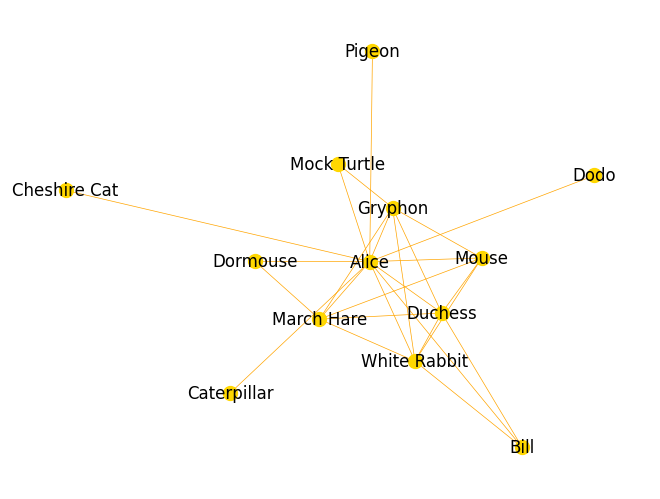

In [12]:

if __name__ == '__main__':
    # File contains a list of characters, reverse sorted by frequency
    # 등장인물, 챕터 정보 변경한 oz.json 파일
    with codecs.open('oz.json', 'r', 'utf-8-sig') as data:
        text = json.load(data)
        cast = text['cast']

        # ##############################################
        # # Build a NetworkX Graph
        # ##############################################
        G = nx.Graph()
        G.name = "The Social Network of Oz"
        pairs = cooccurrence(text, cast)

        for pair, wgt in pairs.items():
            if wgt>0:
                G.add_edge(pair[0], pair[1], weight=wgt)
        # # Make Dorothy the center
        D = nx.ego_graph(G, "Alice")
        edges, weights = zip(*nx.get_edge_attributes(D, "weight").items())
        # # Push nodes away that are less related to Dorothy
        pos = nx.spring_layout(D, k=.5, iterations=40)
        nx.draw(D, pos, node_color="gold", node_size=100, edgelist=edges,
                 width=.5, edge_color="orange", with_labels=True, font_size=12)
        plt.show()